# Dropout

Link to the master thesis that described dropout and its mathematical foundation: http://www.cs.toronto.edu/~nitish/msc_thesis.pdf, I think Hinton came up with the idea but this student formalized it. 

- Dropping out means removing a neuron from the network, along with all of its incoming and outgoing edges
- You usually set some $p$ which determines the probability you drop the neuron
- This is done independently for each unit and each training data point
- You can actually think about this as creating ensemble models.
    - Say you have a network with $n$ units. With dropout, each unit can either be on or off, meaning that you can have $2^n$ subsets of the original networks (or as they put it "thinned neural networks")
    - Unlike in true ensemble methods, you don't need to learn more weights since we are just sampling from one master network
- Here they describe a method to scale the activations of neurons during inference. They suggest that we multiply the neuron's output by $p$ during inference to make it so the expected output of each neuron matches what they trained on.
    - As a simple example, if a neuron has $p=0.5$ and outputs 10 then the next layer will expect about an average of 5 from that neuron. But if during inference we set $p=0$ then suddenly the average jumps to 10 and the network might get confused.
    - Apparently, today we just scale the output during training and then leave inference as is. So in training if $p=0.5$ then we will scale the neurons output by $\frac{1}{p}$. This is done to keep inference nice and efficient.
- You can also use dropout on the input to add noise
- They suggest that applying a max-norm regularization on the weights (where we ensure that $||w_i||_2<c$) allows us to increase the learning rate without the possibility of weights blowing up
    - I went on a bit of a tangent with Gemini about why dropout makes the gradient noisy. In my head, gradients don't really scale based on how many neurons are there per layer, e.g. if there is a layer with 10 neurons and they output $\hat{y}$ and another layer with one neuron that also outputs $\hat{y}$, their gradients will be identical and the wide layer wouldn't have gradients $\frac{1}{10}$ of the other one. So if that is the case, why would turning off some neurons affect the gradient? Well, when turning off the gradients the output likely gets worse so our error term will be larger meaning that the gradient itself will also be bigger and hence the noise that they discuss.
- When setting neurons output to 0 we naturally also turn off any weight updates for that neuron since the gradient will also be 0.
- NN exhibit co-adaptation where neurons become overdependent on each other. Dropout naturally remedies this
- Also neuron activations become sparser 

### Code
Implementing this in scratch would've been pretty trivial, so I opted for some experiments. TBH the code here is not the most educational, I just wanted to visualize a couple of things and see if my intuition checked out. Also for graphing and defining training loops I mostly used AI.

Apparently, dropout isn't great for CNN's because even when you drop a neuron the model can still kind of interpolate it from the neighbors and what not. In the thesis, they use linear layers, so that's what I'll opt to do. We use MNSIT for the data here.

In [62]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [31]:
training_data = datasets.MNIST(
    root="../data", 
    train=True,  
    download=True, 
    transform=ToTensor() 
)

test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

indices = list(range(1024))
subset_train_dataset = Subset(training_data, indices)

train_loader = DataLoader(subset_train_dataset, batch_size = 16, shuffle=True)
test_loader = DataLoader(test_data, batch_size = 16, shuffle=True)

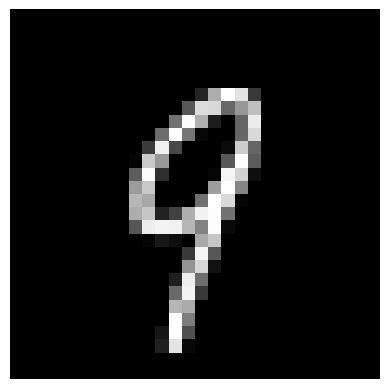

In [12]:
cols = 3
rows = 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx] 
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [16]:
class Model(nn.Module):
    def __init__(self, input_p=0.2, layer_p=0.5):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)
        self.relu = nn.ReLU()
        self.layer_dropout = nn.Dropout(p=layer_p)
        self.input_dropout = nn.Dropout(p=input_p)
        

    def forward(self, x):
        x = self.flatten(x)
        x = self.input_dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.layer_dropout(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.layer_dropout(x)
        
        x = self.fc3(x)
        return x

In [25]:
def train(model, dataloader, loss_fn, optimizer):
    loss_history = []
    # we are goig to track variances of the gradients here (AI written)
    grad_variances = {name: [] for name, param in model.named_parameters() if param.requires_grad}
    
    model.train()
    for x, y in dataloader:
        pred = model(x)
        loss = loss_fn(pred, y)
        loss_history.append(loss.item())

        optimizer.zero_grad() 
        loss.backward()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.grad is not None:
                    v = torch.var(param.grad).item()
                    grad_variances[name].append(v)

        optimizer.step()

    return loss_history, grad_variances

def test(model, dataloader, loss_fn):
    num_batches = len(dataloader)
    size = len(dataloader.dataset)
    loss, correct = 0,0
    with torch.no_grad():
        for x,y in dataloader:
            pred = model(x)
            loss += loss_fn(pred,y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()


    return (loss / num_batches), (correct / size)

### Experiments
I wanted to see if the variances of the gradients do increase as dropout increases. So here we trained 5 different models with increasing dropout rates and tracked the variances of the gradients in the last layer (that's where the gradient variances are the highest). Additionally, the models were not trained for that many epochs or with that much data, so test accuracy is not very indicative of true preformance.

In [78]:
epochs = 5
lr = 0.01
loss_fn = nn.CrossEntropyLoss()
dropout_rates = [0.0, 0.1, 0.3, 0.5, 0.7]

all_variances = []
all_losses = []
all_labels = []

for p in dropout_rates:
    print(f"--- Starting Training: Dropout p={p} ---")
    
    model = Model(input_p=0, layer_p=p)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    
    model_loss_history = []
    model_var_history = {name: [] for name, param in model.named_parameters() if param.requires_grad}
    
    for epoch in range(epochs):
        losses, variances = train(model, train_loader, loss_fn, optim)
        
        model_loss_history.extend(losses)
        for name in model_var_history:
            model_var_history[name].extend(variances[name])
            

    all_losses.append(model_loss_history)
    all_variances.append(model_var_history)
    all_labels.append(f"p={p}")
    test_loss, acc = test(model, test_loader, loss_fn)
    print(f"Final Test Loss: {test_loss} || Test Accuracy: {acc}")

--- Starting Training: Dropout p=0.0 ---
Final Test Loss: 0.7029580941694789 || Test Accuracy: 0.8585
--- Starting Training: Dropout p=0.1 ---
Final Test Loss: 1.5703555056345648 || Test Accuracy: 0.7427
--- Starting Training: Dropout p=0.3 ---
Final Test Loss: 1.4607692958533764 || Test Accuracy: 0.7262
--- Starting Training: Dropout p=0.5 ---
Final Test Loss: 2.1459003207921983 || Test Accuracy: 0.6507
--- Starting Training: Dropout p=0.7 ---
Final Test Loss: 2.2392283133506776 || Test Accuracy: 0.4566


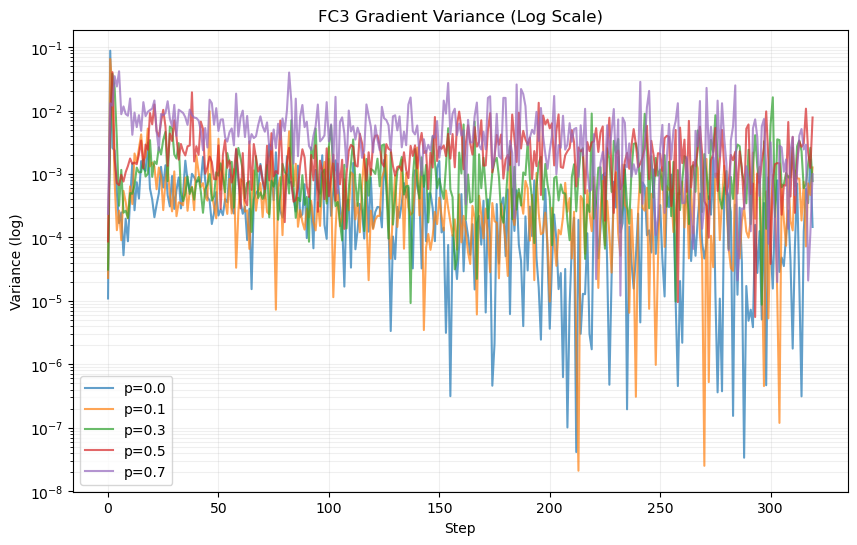

In [79]:
def plot_compare_n_fc3(vars_list, labels=None):
    plt.figure(figsize=(10, 6))
    
    for i, vars_dict in enumerate(vars_list):
        label = labels[i] if labels else f"Model {i+1}"
        plt.plot(vars_dict["fc3.weight"], label=label, alpha=0.7)
    
    plt.yscale('log') # This fixes the scaling issue
    plt.title("FC3 Gradient Variance (Log Scale)")
    plt.xlabel("Step")
    plt.ylabel("Variance (log)")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

plot_compare_n_fc3(all_variances, labels=all_labels)

As we can see the variances do increase with the dropout rates. There is nearly an order of magnitude difference between p=0 and p=0.7. Cool.

Also below we will see that the training becomes less stable. This is not surprising (honestly we can call it intentional). 

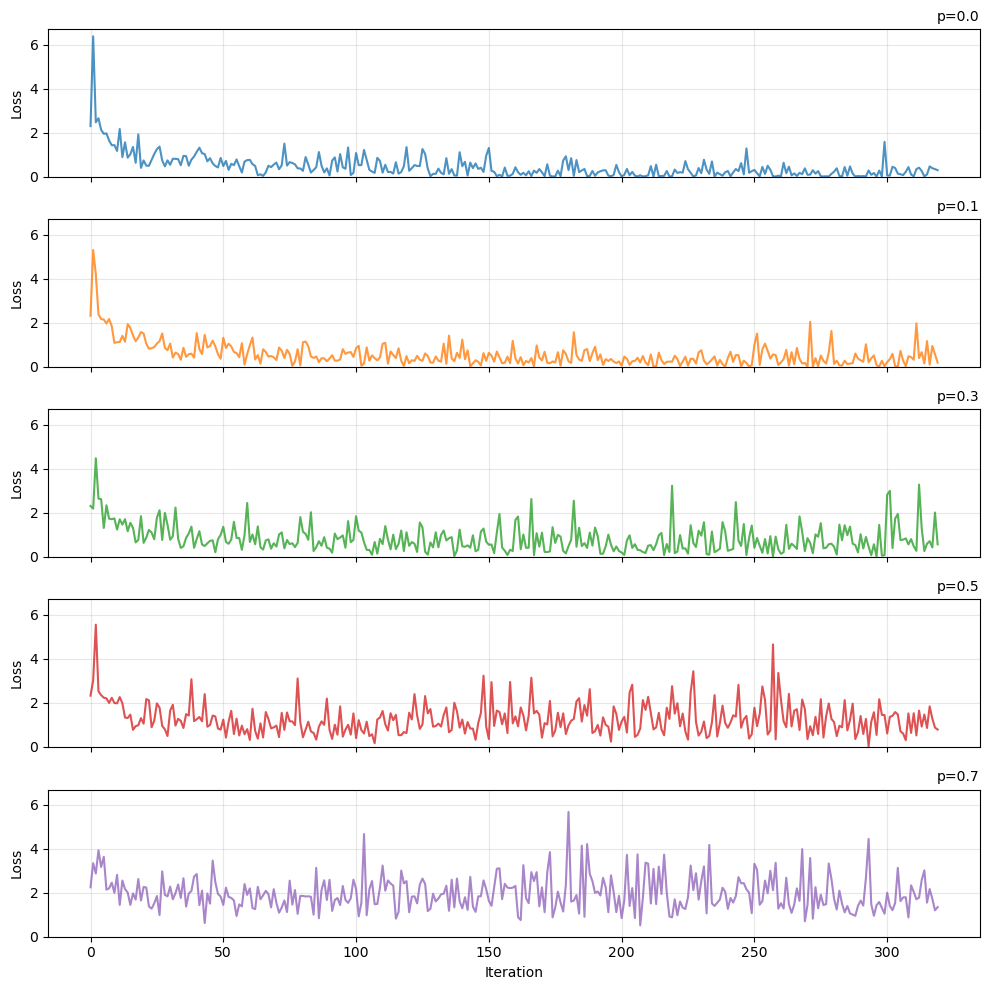

In [80]:
def plot_loss_comparison(loss_list, labels=None):
    n = len(loss_list)
    all_values = [v for history in loss_list for v in history]
    global_max = max(all_values) if all_values else 1.0
    
    fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n), sharex=True)
    
    if n == 1: axes = [axes]
    
    for i, losses in enumerate(loss_list):
        label = labels[i] if labels else f"Model {i+1}"
        axes[i].plot(losses, color=f"C{i}", alpha=0.8)
        
        axes[i].set_ylim(0, global_max * 1.05)
        
        axes[i].set_ylabel("Loss")
        axes[i].set_title(label, loc='right', fontsize=10)
        axes[i].grid(True, alpha=0.3)
    
    plt.xlabel("Iteration")
    plt.tight_layout()
    plt.show()
    

plot_loss_comparison(all_losses, all_labels)

I had a theory that since the variances of the gradients increase as we increase the dropout rate then using an optimizer like Adam that accounts for variances would be more important for higher dropout models. I figured that Adam's training will be more stable and be more immune to higher variances and that SGD with momentum would struggle as $p$ increases.

To be honest I do not know how to interpret the results from this small experiment. First of all, learning rates significantly impact SGD vs Adam performance, I thought that they'd be pretty similar. I was also surprised that Adam became so unstable, I though that if anything it would converge slower than SGD with momentum, but not this. This whole discussion was more about optimizers than dropout tbh, I just suddenly got very curious of what was happening here. Spent an hour or two with Gemini trying to work this out but nothing really made sense to me. Even saw an old stackexchange post about the bound of Adam's update size: https://math.stackexchange.com/questions/3325577/the-upper-bound-of-the-effective-stepsize-of-the-adam-optimizer 

I hope to come back to this ordeal at some point, very interested in what is happening here.

In [99]:
epochs = 20
lrs = [0.001, 0.01]
loss_fn = torch.nn.CrossEntropyLoss()
dropout_rates = [0.0, 0.3, 0.5]

opt_configs = [
    {"name": "Adam", "class": torch.optim.Adam, "kwargs": {}},
    {"name": "SGD",  "class": torch.optim.SGD,  "kwargs": {"momentum": 0.9}}
]

all_losses = []
all_labels = []
trained_results = {}

print(f"{'Optimizer':<10} | {'LR':<7} | {'Dropout':<8} | {'Test Loss':<10} | {'Test Acc':<10}")
print("-" * 55)

for lr in lrs:
    for p in dropout_rates:
        for opt in opt_configs:
            model = Model(input_p=0, layer_p=p)
            optimizer = opt['class'](model.parameters(), lr=lr, **opt['kwargs'])
            
            model_loss_history = []
            for epoch in range(epochs):
                batch_losses, _ = train(model, train_loader, loss_fn, optimizer)
                model_loss_history.extend(batch_losses)
            
            model.eval()
            test_loss, acc = test(model, test_loader, loss_fn)
            
            label = f"{opt['name']} (lr={lr}, p={p})"
            all_losses.append(model_loss_history)
            all_labels.append(label)
            trained_results[label] = model
            
            print(f"{opt['name']:<10} | {lr:<7} | {p:<8} | {test_loss:<10.4f} | {acc:<10.2%}")

Optimizer  | LR      | Dropout  | Test Loss  | Test Acc  
-------------------------------------------------------
Adam       | 0.001   | 0.0      | 0.4838     | 90.41%    
SGD        | 0.001   | 0.0      | 0.5576     | 83.60%    
Adam       | 0.001   | 0.3      | 0.4872     | 90.28%    
SGD        | 0.001   | 0.3      | 0.5787     | 82.17%    
Adam       | 0.001   | 0.5      | 0.5126     | 89.37%    
SGD        | 0.001   | 0.5      | 0.5850     | 82.69%    
Adam       | 0.01    | 0.0      | 1.3579     | 84.52%    
SGD        | 0.01    | 0.0      | 0.5147     | 87.76%    
Adam       | 0.01    | 0.3      | 1.5015     | 82.10%    
SGD        | 0.01    | 0.3      | 0.4739     | 88.44%    
Adam       | 0.01    | 0.5      | 1.0382     | 79.42%    
SGD        | 0.01    | 0.5      | 0.4654     | 88.26%    


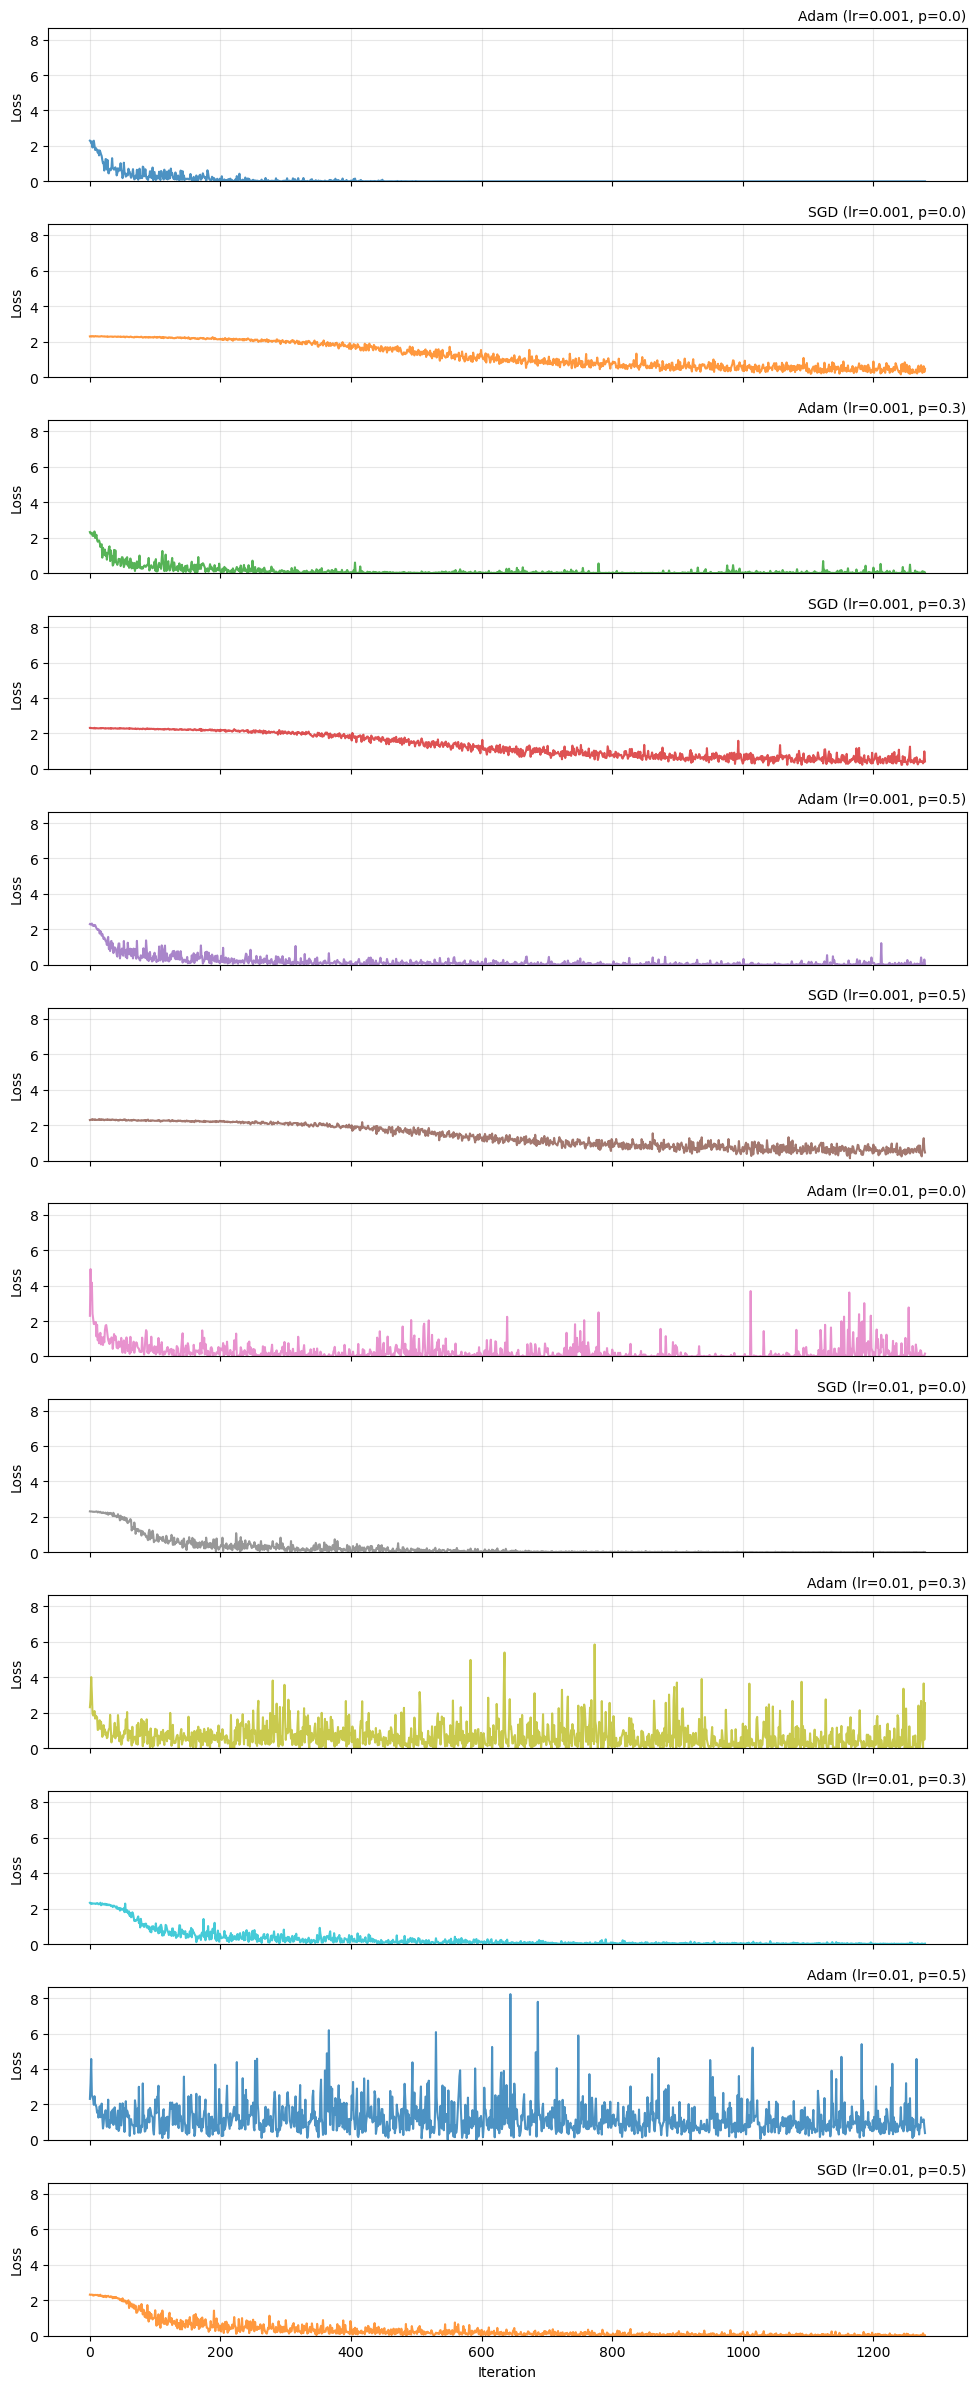

In [100]:
plot_loss_comparison(all_losses, labels=all_labels)